# BGE top-20: similarity vs MMR diversification

Both methods start from the identical BGE top-20 candidate pool on the 350/50 corpus. The baseline takes the five highest-similarity chunks. MMR selects five chunks by balancing query relevance with novelty relative to already-selected chunks. The primary paired comparison uses the best setting from the sensitivity sweep, λ=0.9.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from evaluate_diversification import run_diversification_evaluation
pd.set_option('display.max_colwidth', 150)
PROJECT_ROOT

C:\Users\spide\Desktop\Project Folder - Govtech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('C:/Users/spide/Desktop/Project Folder - Govtech')

In [2]:
result = run_diversification_evaluation(PROJECT_ROOT, batch_size=32)
result['run_info']

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12923.73it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:  50%|█████     | 1/2 [00:00<00:00,  3.79it/s]

Batches: 100%|██████████| 2/2 [00:00<00:00,  5.71it/s]

...

Batches:  67%|██████▋   | 6/9 [00:16<00:07,  2.62s/it]

Batches:  78%|███████▊  | 7/9 [00:18<00:04,  2.13s/it]

Batches:  89%|████████▉ | 8/9 [00:18<00:01,  1.67s/it]

Batches: 100%|██████████| 9/9 [00:18<00:00,  2.09s/it]

{'workbook_rows': 60,
 'excluded_rows': 9,
 'remaining_rows': 51,
 'scored_rows': 51,
 'unscored_rows': 0,
 'corpus': '350 words / 50 overlap',
 'chunks': 280,
 'model': 'BAAI/bge-small-en-v1.5',
 'candidate_k': 20,
 'final_k': 5,
 'primary_lambda': 0.9,
 'lambda_sweep': [0.5, 0.6, 0.7, 0.8, 0.9],
 'mmr_formula': 'lambda * query_similarity - (1-lambda) * max_similarity_to_selected',
 'normalized_embeddings': True}

## Retrieval metrics and λ sensitivity

In [3]:
summary = result['summary']
summary.style.format('{:.3f}').highlight_max(axis=0, color='#c6efce')

,recall@1,recall@3,recall@5,mrr
method,,,,
Similarity top-5,0.553,0.734,0.803,0.802
MMR λ=0.5,0.553,0.648,0.786,0.774
MMR λ=0.6,0.553,0.707,0.799,0.780
MMR λ=0.7,0.553,0.708,0.829,0.793
MMR λ=0.8,0.553,0.744,0.835,0.799
MMR λ=0.9,0.553,0.760,0.875,0.809


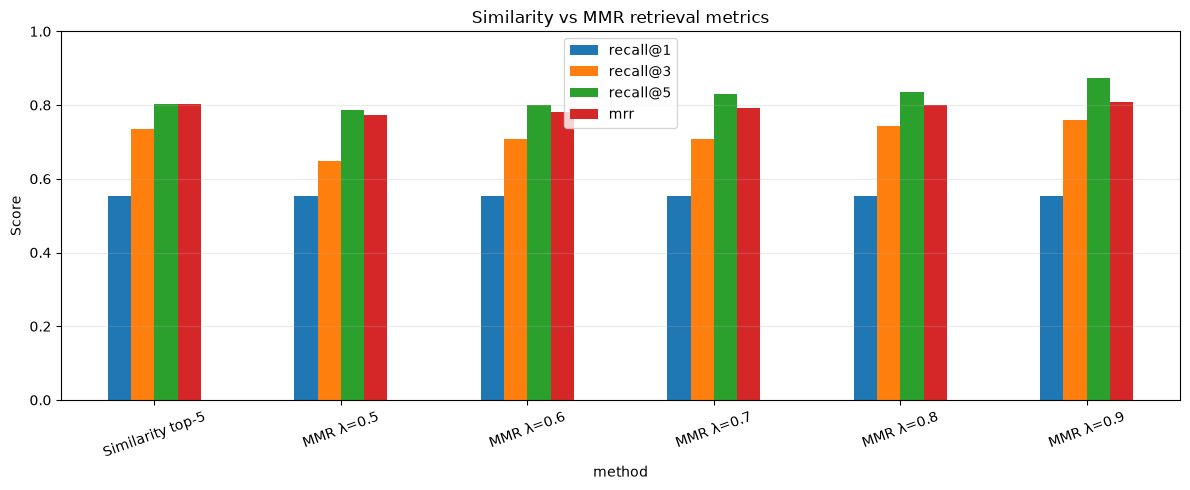

In [4]:
ax = summary.plot(kind='bar', figsize=(12, 5), ylim=(0, 1), rot=20)
ax.set_title('Similarity vs MMR retrieval metrics')
ax.set_ylabel('Score'); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## Diversity diagnostics

In [5]:
result['diversity'].round(3)

,unique_sources@5,duplicate_fraction@5,max_source_share@5,candidate_recall@20,diversification_candidate
method,,,,,
Similarity top-5,3.275,0.345,0.498,0.967,0.157
MMR λ=0.5,3.941,0.212,0.388,0.967,0.098
MMR λ=0.6,3.804,0.239,0.416,0.967,0.078
MMR λ=0.7,3.765,0.247,0.412,0.967,0.039
MMR λ=0.8,3.588,0.282,0.439,0.967,0.078
MMR λ=0.9,3.510,0.298,0.463,0.967,0.078


## Paired error analysis: similarity vs primary MMR (λ=0.9)

In [6]:
paired = result['paired']
paired.loc[paired['delta_recall@5'] > 0, [
    'question_id','baseline_question','baseline_gold_sources','baseline_top5_sources',
    'mmr_top5_sources','delta_recall@5','delta_mrr','delta_unique_sources@5'
]].sort_values('delta_recall@5', ascending=False)

,question_id,baseline_question,baseline_gold_sources,baseline_top5_sources,mmr_top5_sources,delta_recall@5,delta_mrr,delta_unique_sources@5
5,Q6,"What household income ceilings apply to an HDB housing loan for families, extended families and singles?",HDB08,"HDB06, HDB01, HDB01, HDB01, HDB05","HDB06, HDB01, HDB08, HDB05, HDB01",1.000000,0.190476,1
9,Q10,How long is the Option to Purchase valid after it is granted for a resale flat?,HDB12,"HDB02, HDB02, HDB01, HDB01, HDB01","HDB02, HDB08, HDB12, HDB02, HDB01",1.000000,0.208333,2
11,Q12,What are some of the main purposes of CPF described in CPF 101?,CPF02,"CPF07, CPF07, CPF01, CPF07, CPF07","CPF07, CPF01, CPF07, CPF07, CPF02",1.000000,0.033333,1
45,Q53,"I'm 30 and single, so I can buy any HDB resale flat on my own as long as I can afford it, right?","HDB02, HDB08","HDB03, HDB01, HDB01, HDB01, HDB01","HDB03, HDB01, HDB02, HDB01, HDB04",0.500000,0.166667,2
35,Q36,I am 35 and single. Exactly how much housing grant will I receive for the flat I am considering?,"HDB02, HDB03, HDB04","HDB03, HDB04, HDB03, HDB06, HDB03","HDB03, HDB04, HDB03, HDB03, HDB02",0.333333,0.000000,0


In [7]:
paired.loc[paired['delta_recall@5'] < 0, [
    'question_id','baseline_question','baseline_gold_sources','baseline_top5_sources',
    'mmr_top5_sources','delta_recall@5','delta_mrr','delta_unique_sources@5'
]].sort_values('delta_recall@5')

,question_id,baseline_question,baseline_gold_sources,baseline_top5_sources,mmr_top5_sources,delta_recall@5,delta_mrr,delta_unique_sources@5
44,Q45,I am eligible to buy a flat. Does that automatically mean I will receive every CPF housing grant listed on HDB's site?,"HDB01, HDB02, HDB03, HDB05, HDB06","HDB01, HDB02, HDB06, HDB07, HDB05","HDB01, HDB06, HDB02, HDB07, HDB01",-0.2,0.0,-1


In [8]:
paired.loc[(paired['delta_unique_sources@5'] > 0) & (paired['delta_recall@5'] == 0), [
    'question_id','baseline_question','baseline_gold_sources','baseline_top5_sources',
    'mmr_top5_sources','delta_mrr','delta_unique_sources@5'
]].head(50)

,question_id,baseline_question,baseline_gold_sources,baseline_top5_sources,mmr_top5_sources,delta_mrr,delta_unique_sources@5
0,Q1,Who can buy an HDB flat under the couples and families routes described by HDB?,HDB01,"HDB01, HDB02, HDB01, HDB01, HDB01","HDB01, HDB01, HDB01, HDB07, HDB02",0.00000,1
10,Q11,What are the main CPF accounts described in the CPF overview?,CPF01,"CPF02, CPF07, CPF07, CPF01, CPF07","CPF02, CPF07, CPF07, CPF08, CPF01",-0.05000,1
12,Q13,Which CPF account can generally be used for a home purchase?,CPF03,"HDB09, CPF04, CPF02, CPF01, CPF02","HDB09, CPF04, CPF02, CPF01, HDB07",-0.02381,1
26,Q27,"If a family is buying a resale flat, what must be established before EHG for Families is considered?","HDB05, HDB06","HDB05, HDB04, HDB04, HDB05, HDB04","HDB05, HDB04, HDB04, HDB05, HDB01",0.00000,1
38,Q39,I used CPF for my home. Tell me the exact dollar amount I must refund if I sell today.,CPF06,"CPF06, CPF06, HDB08, CPF04, CPF06","CPF06, CPF06, HDB08, CPF04, HDB09",0.00000,1
41,Q42,I am a second-timer. Does the Step-Up CPF Housing Grant definitely apply to me?,HDB07,"HDB07, HDB07, HDB02, HDB06, HDB02","HDB07, HDB07, HDB02, HDB06, HDB05",0.00000,1
47,Q55,"When I sell my property, I only need to refund the original CPF principal and never any accrued interest, right?",CPF06,"CPF06, CPF06, CPF04, CPF06, HDB08","CPF06, CPF06, CPF04, HDB07, HDB08",0.00000,1
49,Q57,What CPF OA interest rate applies from 1 July 2026 to 30 September 2026?,CPF10,"CPF10, CPF09, CPF02, CPF02, CPF02","CPF10, CPF09, CPF02, CPF02, HDB01",0.00000,1


In [9]:
result['by_category'].round(3)

recall@1  recall@3  recall@5    mrr
method           category                                                   
MMR λ=0.5        adversarial_misleading     0.500     0.625     0.625  0.625
                 conditional                0.700     0.750     0.800  0.842
                 direct_answerable          0.533     0.600     0.867  0.645
                 multi_hop                  0.333     0.483     0.567  0.771
                 partially_answerable       0.587     0.723     0.890  0.920
                 temporal                   1.000     1.000     1.000  1.000
MMR λ=0.6        adversarial_misleading     0.500     0.625     0.625  0.625
                 conditional                0.700     0.800     0.850  0.850
                 direct_answerable          0.533     0.667     0.867  0.650
                 multi_hop                  0.333     0.533     0.567  0.771
                 partially_answerable       0.587     0.823     0.910  0.933
                 temporal                   1.000     1.000     1.000  1.000
MMR λ=0.7        adversarial_misleading     0.500     0.500     0.750  0.578
                 conditional                0.700     0.800     0.850  0.850
                 direct_answerable          0.533     0.667     0.867  0.665
                 multi_hop                  0.333     0.567     0.700  0.814
                 partially_answerable       0.587     0.843     0.877  0.950
                 temporal                   1.000     1.000     1.000  1.000
MMR λ=0.8        adversarial_misleading     0.500     0.750     0.875  0.646
                 conditional                0.700     0.800     0.850  0.850
                 direct_answerable          0.533     0.733     0.800  0.664
                 multi_hop                  0.333     0.600     0.783  0.820
                 partially_answerable       0.587     0.793     0.877  0.950
                 temporal                   1.000     1.000     1.000  1.000
MMR λ=0.9        adversarial_misleading     0.500     0.875     0.875  0.708
                 conditional                0.700     0.800     0.950  0.875
                 direct_answerable          0.533     0.733     0.867  0.657
                 multi_hop                  0.333     0.633     0.783  0.833
                 partially_answerable       0.587     0.793     0.877  0.950
                 temporal                   1.000     1.000     1.000  1.000
Similarity top-5 adversarial_misleading     0.500     0.750     0.750  0.667
                 conditional                0.700     0.900     0.950  0.900
                 direct_answerable          0.533     0.600     0.667  0.633
                 multi_hop                  0.333     0.650     0.783  0.825
                 partially_answerable       0.587     0.793     0.863  0.950
                 temporal                   1.000     1.000     1.000  1.000

In [10]:
print(f"CSV outputs: {result['output_dir']}")

CSV outputs: C:\Users\spide\Desktop\Project Folder - Govtech\data\experiments\evaluation_diversification_350w_50o
